# MNIST

In [46]:
import numpy as np
from helper_functions import *
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [47]:
X_train = load_images('mnist/train-images-idx3-ubyte/train-images-idx3-ubyte')
y_train = load_labels('mnist/train-labels-idx1-ubyte/train-labels-idx1-ubyte')

X_test = load_images('mnist/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
y_test = load_labels('mnist/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

y_train = y_train.astype(int)
y_test = y_test.astype(int)



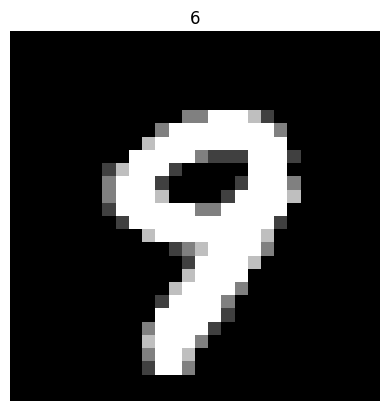

In [48]:
plt.imshow(X_train[5999], cmap='gray')
plt.title(y_train[6000])
plt.axis('off')
plt.show()

### Preprocessing

In [49]:
# Normalize images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension
# From (N,28,28) -> (N,28,28,1)
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)



Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


### Building the CNN

In [50]:
# Build CNN
model = models.Sequential([

    # Input layer (explicit)
    layers.Input(shape=(28, 28, 1)),

    # Conv block 1
    layers.Conv2D(8, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Conv block 2
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Output layer
    layers.Dense(10, activation='softmax')
])

# Summary
model.summary()



Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 26, 26, 8)           │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 13, 13, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 11, 11, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 5, 5, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 128)                 │          51,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,866 (210.41 KB)

 Trainable params: 53,866 (210.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.9250 - loss: 0.2556 - val_accuracy: 0.9818 - val_loss: 0.0701
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9767 - loss: 0.0744 - val_accuracy: 0.9848 - val_loss: 0.0563
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9835 - loss: 0.0530 - val_accuracy: 0.9855 - val_loss: 0.0474
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9874 - loss: 0.0405 - val_accuracy: 0.9870 - val_loss: 0.0458
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9892 - loss: 0.0343 - val_accuracy: 0.9850 - val_loss: 0.0496
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9916 - loss: 0.0272 - val_accuracy: 0.9902 - val_loss: 0.0361
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9927 - loss: 0.0225 - val_accuracy: 0.9888 - val_loss: 0.0429
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9942 - loss: 0.0180 - 

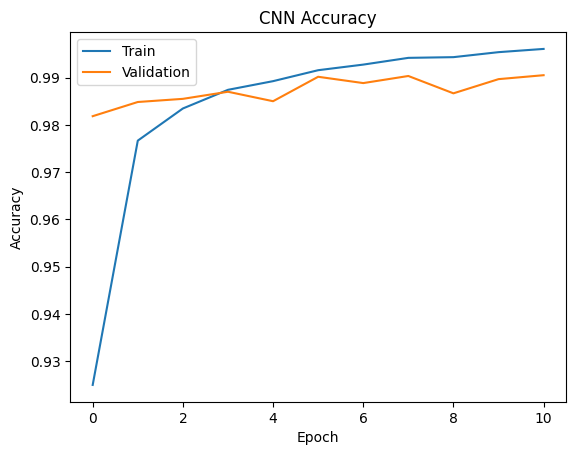

In [51]:
# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',   # watch validation loss
    patience=5,           # wait 3 epochs before stopping
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_cat,
    epochs=20,            # set large max
    batch_size=64,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("Test accuracy:", test_acc)

# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.title("CNN Accuracy")
plt.show()

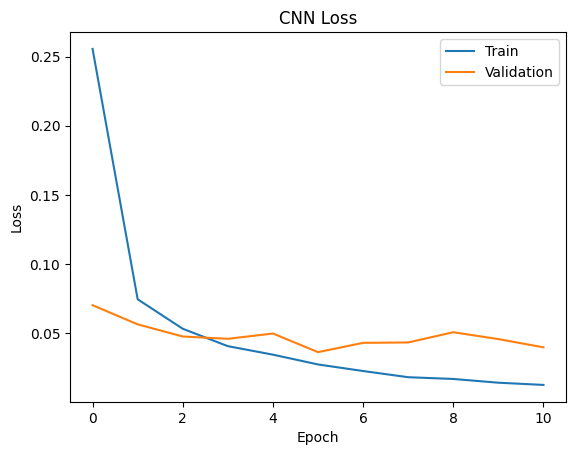

In [52]:
# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.title("CNN Loss")
plt.show()

### SGD

Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.7760 - loss: 0.7540 - val_accuracy: 0.9365 - val_loss: 0.2280
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9262 - loss: 0.2431 - val_accuracy: 0.9553 - val_loss: 0.1563
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9466 - loss: 0.1736 - val_accuracy: 0.9557 - val_loss: 0.1390
Epoch 4/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9579 - loss: 0.1400 - val_accuracy: 0.9652 - val_loss: 0.1218
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9635 - loss: 0.1203 - val_accuracy: 0.9667 - val_loss: 0.1151
Epoch 6/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9676 - loss: 0.1056 - val_accuracy: 0.9708 - val_loss: 0.0976
Epoch 7/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9696 - loss: 0.0975 - val_accuracy: 0.9710 - val_loss: 0.0982
Epoch 8/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9721 - loss: 0.0896 - 

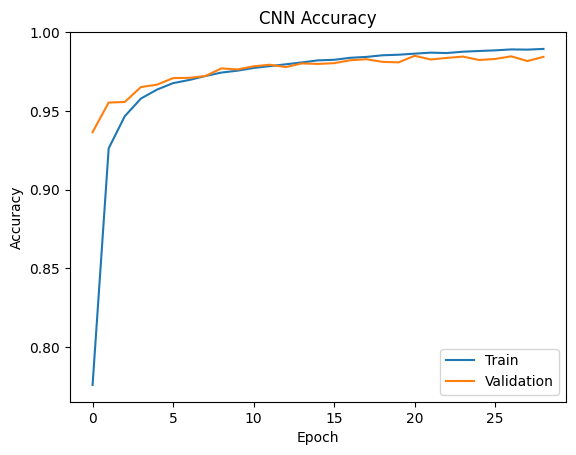

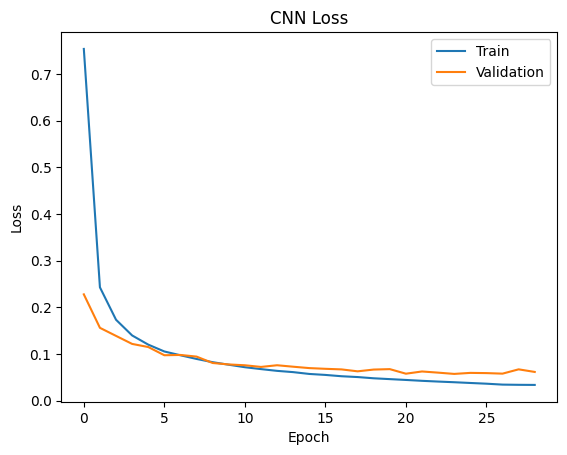

In [53]:
# Build CNN
model = models.Sequential([

    # Input layer (explicit)
    layers.Input(shape=(28, 28, 1)),

    # Conv block 1
    layers.Conv2D(8, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Conv block 2
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Output layer
    layers.Dense(10, activation='softmax')
])


# Compile
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',   # watch validation loss
    patience=5,           # wait 3 epochs before stopping
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_cat,
    epochs=50,            # set large max
    batch_size=64,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("Test accuracy:", test_acc)

# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.title("CNN Accuracy")
plt.show()
# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.title("CNN Loss")
plt.show()